# Week 10 extension — train + evaluate (notebook 10d)

This notebook merges the **training** half (Week 10's Tasks 60–66, formerly
in `10d_extend_and_train.ipynb`) and the **evaluation** half (Tasks 67–70,
formerly in `10e_diffusion_NLL_ablations.ipynb`) into a single Colab-friendly
file. Each Colab session is isolated, so doing both halves in one notebook
means a fresh runtime can pick up where you left off without re-running
setup twice and without risking the `EXPERIMENTS` dict drifting between the
two halves.

## How to use this notebook

There is **one flag at the top** that determines what the notebook does:

- `MODE = "train"` — runs the data-augmentation cells (Tasks 60–63), the
  experiment-menu setup (Tasks 64–65), the training loop (Task 66), and the
  visual sanity check. The training loop is **idempotent**: it skips any
  experiment whose `ckpt_<name>.ckpt` already exists. Run the notebook many
  times with one new entry enabled in `ENABLED_EXPERIMENTS` per session.
- `MODE = "eval"` — skips training, jumps into the NLL ablation pipeline
  (Tasks 67–69), and scores every `ckpt_E*.ckpt` it finds in this directory.

**Recipe:** run with `MODE = "train"` repeatedly (one new experiment per
session) until you have all the checkpoints you want, then flip to
`MODE = "eval"` and run the notebook once to score them.

[**↓ Jump to evaluation (Tasks 67–70)**](#eval-mode)

> The **test split is reserved for the PI**. Every data-loading cell in this
> notebook filters to `split in {"train", "val"}`. Do not change that.


In [19]:
MODE = "eval"   # set to "eval" once you have ckpt_E*.ckpt files to score

assert MODE in ("train", "eval"), f"MODE must be 'train' or 'eval', got {MODE!r}"
TRAIN_MODE = (MODE == "train")
EVAL_MODE  = (MODE == "eval")
print(f"MODE = {MODE!r}  (TRAIN_MODE={TRAIN_MODE}, EVAL_MODE={EVAL_MODE})")


MODE = 'eval'  (TRAIN_MODE=False, EVAL_MODE=True)


In [20]:
# Standard Week 10 setup: locate the repo, install if missing.

import os, subprocess, sys

# Keep this path if working in Colab
# repo_path = "/content/butterflai"

# Use this path if working locally
repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path], check=True)
else:
    try:
        subprocess.run(["git", "-C", repo_path, "pull"], check=True)
    except subprocess.CalledProcessError as e:
        print(f"git pull skipped: {e}")
sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


There is no tracking information for the current branch.
Please specify which branch you want to merge with.
See git-pull(1) for details.

    git pull <remote> <branch>

If you wish to set tracking information for this branch you can do so with:

    git branch --set-upstream-to=origin/<branch> feature/week11



git pull skipped: Command '['git', '-C', '../../', 'pull']' returned non-zero exit status 1.
  Installing from /d0/amunozj/git_repos/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Local
   Device   : cuda
   Seed     : 42


{'in_colab': False,
 'device': device(type='cuda'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

In [21]:
%load_ext autoreload
%autoreload 2

import os, sys, glob, json, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from scipy.stats import norm as sp_norm
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import repeat

import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger, CSVLogger
import wandb


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
# Bootstrap sys.path and locate artifacts.
import os, sys

# Several week directories ship a conditioned_infrastructure.py, but only the
# Week-10/11 copy defines find_week10_artifacts and the Extended* API — the
# Week-09 copy is an older stub. Force week_10 (the copy find_week10_artifacts
# itself resolves to, so no module eviction happens) to the FRONT of sys.path
# so the Week-09 stub can never shadow it, and add week_11 so eval mode can
# import its evaluation.py. Also drop any stale module a prior failed import
# may have cached as the Week-09 stub.
_week09_dir = os.path.abspath(os.path.join(repo_path, "weeks", "week_09"))
_week10_dir = os.path.abspath(os.path.join(repo_path, "weeks", "week_10"))
_week11_dir = os.path.abspath(os.path.join(repo_path, "weeks", "week_11"))
for _p in (_week09_dir, _week11_dir, _week10_dir):   # week_10 inserted last -> resolves first; week_09 trails so its conditioned_infrastructure stub never shadows but unconditioned_infrastructure stays importable
    if _p in sys.path:
        sys.path.remove(_p)
    sys.path.insert(0, _p)
sys.modules.pop("conditioned_infrastructure", None)

from conditioned_infrastructure import find_week10_artifacts
# parquet_v2 is built fresh in Part A every run; raw CSV is needed by the
# eval phase (Task 67 Part 1). Both are listed as required so a missing
# raw CSV fails loudly at setup time rather than at Task 67.
paths = find_week10_artifacts(extra_required=[
    "data/composite_sunspot_groups_peak_area.csv",
])
# find_week10_artifacts resolves conditioned_infrastructure to the week_10
# copy (its home, where the parquet + checkpoints live) and evicts any other
# cached copy. Repoint the *module* to the week_11 copy — that's where THIS
# notebook's API lives (E9–E11 + the cond_*_valid plumbing) — while keeping
# the week_10 artifact paths returned in `paths`.
if _week11_dir in sys.path:
    sys.path.remove(_week11_dir)
sys.path.insert(0, _week11_dir)
sys.modules.pop("conditioned_infrastructure", None)

from unconditioned_infrastructure import make_cosine_schedule
from conditioned_infrastructure import (
    ExtendedConditionalResidualDataset,
    ExtendedConditionalDiffusionLightning,
    train_experiment,
    load_trained_experiment,
    sample_conditional_extended,
    build_model,
    block_cond_concat,
    k_run_combined,
    discover_experiment_checkpoints,
)
from butterflAI_model import ButterflAIModel

import conditioned_infrastructure as _ci
print(f"using conditioned_infrastructure from: {_ci.__file__}")

_WEEK10_DIR = paths["week10_dir"]
PARQUET_V2  = os.path.join(_WEEK10_DIR, "diffusion_windows_v2.parquet")
CKPT_DIR    = _WEEK10_DIR

classical   = ButterflAIModel(paths["classical_weights"])

LAT_BINS    = np.linspace(0, 45, 16)
BIN_WIDTH   = 3.0
BIN_CENTERS = 0.5 * (LAT_BINS[:-1] + LAT_BINS[1:])

T = 200
alpha_np, sigma_np, _ = make_cosine_schedule(T=T, s=0.008)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the v1 parquet — we extend it but never modify it.
# Test split is reserved for the PI.
windows_v1 = pd.read_parquet(paths["parquet_v1"])
windows_v1 = windows_v1.loc[windows_v1["split"].isin(["train", "val"])].reset_index(drop=True)
print(f"v1 parquet (train+val only): {len(windows_v1)} rows")
print(f"  splits: {windows_v1['split'].value_counts().sort_index().to_dict()}")
print(f"  cycles: {sorted(windows_v1['cycle'].unique())}")
print(f"v2 parquet target: {PARQUET_V2}")
print(f"device           : {device}")


using conditioned_infrastructure from: /d0/amunozj/git_repos/butterflai/weeks/week_11/conditioned_infrastructure.py
v1 parquet (train+val only): 287 rows
  splits: {'train': 232, 'val': 55}
  cycles: [np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
v2 parquet target: /d0/amunozj/git_repos/butterflai/weeks/week_10/diffusion_windows_v2.parquet
device           : cuda


---
## Part A — Build the augmented parquet

We're going to add three families of new conditioning columns to the
v1 parquet:

1. **Cycle and hemisphere identifiers** — a normalized cycle number and
   a north/south indicator.
2. **Opposite-hemisphere summaries** — for each window, the
   *contemporaneous* opposite-hemisphere activity. This is not leakage:
   contemporaneous opposite-hemisphere activity is operationally
   observable (an operational forecaster on the day of the same window
   would have it).
3. **Smoothed-area trajectory** — the past `K` windows of `area_smoothed`
   for the same hemicycle, as a short autoregressive history.

The build cells **rewrite `diffusion_windows_v2.parquet` every run**. We
deliberately do *not* gate on file existence — if you change how a
column is computed and don't see the change downstream, the most
common explanation is "the file was cached." We avoid that failure
mode by always rewriting.


---
## Task 60 — Cycle and hemisphere identifiers

Add two new columns to the dataframe:

- `cycle_norm`: cycle number rescaled to roughly `[-1, +1]` over the
  train range. The point of normalization is not to be exactly in
  `[-1, +1]` — it's to put the input on the same numerical scale as the
  other conditioning vectors so the network doesn't have to learn an
  outsized weight for it.
- `hemi_id`: `+1` for north, `-1` for south.

Both are cheap and let downstream experiments test whether
*structural* per-cycle / per-hemisphere effects survive once amplitude
is controlled for.


In [23]:
# Task 60 — add cycle_norm and hemi_id.

windows_aug = windows_v1.copy()

# TODO: compute cycle_norm. Use train-set cycle range so this is well
# defined for both splits. Aim for the train cycle range to map roughly
# onto [-1, +1].
_train_cycles = windows_aug.loc[windows_aug["split"] == "train", "cycle"]
_cmin, _cmax  = _train_cycles.min(), _train_cycles.max()
windows_aug["cycle_norm"] = 2.0 * (windows_aug["cycle"] - _cmin) / (_cmax - _cmin) - 1.0

# TODO: compute hemi_id. +1 north, -1 south.
windows_aug["hemi_id"] = np.where(windows_aug["hemisphere"] == "north", 1.0, -1.0)

print("cycle_norm range:", windows_aug["cycle_norm"].min(), windows_aug["cycle_norm"].max())
print("hemi_id values  :", windows_aug["hemi_id"].unique())


cycle_norm range: -1.0 1.0
hemi_id values  : [-1.  1.]


---
## Task 61 — Opposite-hemisphere conditioning

For each window in hemisphere *h* at a given calendar time, attach the
contemporaneous opposite-hemisphere activity summary:

- `opp_area_smoothed` — opposite hemisphere's `area_smoothed`
- `opp_mu_universal`  — opposite hemisphere's `mu_universal`
- `opp_amplitude`     — opposite hemisphere's `amplitude`
- `opp_valid`         — 1 if a matching opposite row was found at the
  same calendar time, else 0.

When `opp_valid == 0` (no matching opposite row), impute with the
**train-set mean** of each opposite-* column. This way the network always
sees a defined input; downstream you can decide whether to gate on the
mask.

**Implementation note — match in calendar time, not phase.** The
parquet stores `tau_center`, which is *phase relative to each
hemicycle's own `t0`*. North and south hemicycles of the same cycle
start at different `t0`, so they never share a `tau_center` value — a
naive merge on `tau_center` finds **zero** matches. Convert to calendar
year first (`year = tau_center + t0`, with `t0` from the classical
model), then match the opposite hemisphere by nearest calendar time
within the same cycle (`pd.merge_asof`, tolerance ≈ half a 6-month
window). This is what "contemporaneous" actually means.

In [24]:
# Task 61 — attach contemporaneous opposite-hemisphere summaries.
#
# Contemporaneity is in *calendar* time. `tau_center` is phase relative to
# each hemicycle's own t0, so north and south never share a tau_center —
# a naive merge on tau_center finds zero matches. Convert to calendar year
# (year = tau_center + t0) and match the opposite hemisphere by nearest
# calendar time within the same cycle.
_t0 = {(int(c), str(h)): float(classical.lookup_t0(int(c), h))
       for (c, h) in classical.known_hemicycles()}

def _to_year(row):
    key = (int(row["cycle"]), str(row["hemisphere"]))
    return float(row["tau_center"]) + _t0[key] if key in _t0 else np.nan

windows_aug["_year_center"] = windows_aug.apply(_to_year, axis=1)

# Right side: opposite hemisphere, relabeled so a north row matches the
# (formerly) south rows, columns renamed with the "opp_" prefix.
_flip = {"north": "south", "south": "north"}
_right = (windows_aug
          .loc[:, ["cycle", "_year_center", "hemisphere",
                   "area_smoothed", "mu_universal", "amplitude"]]
          .assign(hemisphere=lambda d: d["hemisphere"].map(_flip))
          .rename(columns={
              "area_smoothed": "opp_area_smoothed",
              "mu_universal":  "opp_mu_universal",
              "amplitude":     "opp_amplitude",
          }))

# merge_asof matches each row to the nearest opposite-hemisphere row in
# calendar time, within ~half a 6-month window. Both sides must be sorted
# by the match key; carry a row id so we can restore the original order.
_TOL = 0.4   # years
_left = (windows_aug.reset_index().rename(columns={"index": "_rowid"})
         .sort_values("_year_center"))
_right = _right.sort_values("_year_center")
_merged = pd.merge_asof(
    _left, _right, on="_year_center", by=["cycle", "hemisphere"],
    direction="nearest", tolerance=_TOL,
)
windows_aug = (_merged.sort_values("_rowid")
               .drop(columns=["_rowid", "_year_center"])
               .reset_index(drop=True))

windows_aug["opp_valid"] = windows_aug["opp_area_smoothed"].notna().astype(np.float32)

# Impute missing opp_* values with train-set means.
_opp_cols = ["opp_area_smoothed", "opp_mu_universal", "opp_amplitude"]
_train_mask = (windows_aug["split"] == "train") & (windows_aug["opp_valid"] == 1.0)
for _c in _opp_cols:
    _mean = windows_aug.loc[_train_mask, _c].mean()
    windows_aug[_c] = windows_aug[_c].fillna(_mean)

print(f"opp_valid coverage: {windows_aug['opp_valid'].mean():.3f}")
print(f"opp_area_smoothed (train, valid): "
      f"mean={windows_aug.loc[_train_mask, 'opp_area_smoothed'].mean():.3f}, "
      f"std={windows_aug.loc[_train_mask, 'opp_area_smoothed'].std():.3f}")

opp_valid coverage: 0.648
opp_area_smoothed (train, valid): mean=96.913, std=42.818


---
## Task 62 — Smoothed-area trajectory (cycle history)

For each window, attach the previous `K` values of `area_smoothed`
from the same hemicycle (same `cycle` AND same `hemisphere`), ordered
chronologically by `tau_center`. Columns: `area_lag1`, `area_lag2`, …,
`area_lagK`.

`area_lag1` is the *previous* window's smoothed area; `area_lagK` is
the one K steps back. Boundary windows (near the start of a hemicycle,
where fewer than K prior windows exist) get train-set-mean imputation
and a `traj_valid` column set to 0 for that row.

The point: cycle *history* is information that amplitude alone misses.
A window 6 months into a strong cycle and a window 6 months from the
end of a strong cycle have similar amplitude but very different
trajectory.

**Implementation hint:** sort within each hemicycle by `tau_center`,
then shift the `area_smoothed` series by 1, 2, …, K.


In [25]:
# Task 62 — attach the smoothed-area trajectory (K lagged values).

K_LAGS = 4

# TODO: within each (cycle, hemisphere) group, sort by tau_center and
#       produce K columns of shifted area_smoothed.
_sorted = windows_aug.sort_values(["cycle", "hemisphere", "tau_center"])

_lag_cols = [f"area_lag{k}" for k in range(1, K_LAGS + 1)]
for k, col in enumerate(_lag_cols, start=1):
    _sorted[col] = _sorted.groupby(["cycle", "hemisphere"])["area_smoothed"].shift(k)

# A row is traj_valid iff *all* K lags exist.
_sorted["traj_valid"] = (~_sorted[_lag_cols].isna().any(axis=1)).astype(np.float32)

# TODO: impute boundary NaNs with train-set means.
_train_mask = (_sorted["split"] == "train") & (_sorted["traj_valid"] == 1.0)
for col in _lag_cols:
    _mean = _sorted.loc[_train_mask, col].mean()
    _sorted[col] = _sorted[col].fillna(_mean)

windows_aug = _sorted.sort_index()  # restore original row order

print(f"traj_valid coverage: {windows_aug['traj_valid'].mean():.3f}")
print(f"lag columns: {_lag_cols}")


traj_valid coverage: 0.721
lag columns: ['area_lag1', 'area_lag2', 'area_lag3', 'area_lag4']


---
## Task 63 — Write `diffusion_windows_v2.parquet` and sanity-check

Write the augmented dataframe. Sanity checks before we trust it
downstream:

- Row count unchanged from v1 (we did not gain or lose any windows).
- Every original v1 column is preserved bit-for-bit.
- New cond columns are finite **wherever the validity mask says they
  should be**.
- `split` column is unchanged.


In [26]:
# Task 63 — write v2 + sanity checks.

# Sanity 1: row count.
assert len(windows_aug) == len(windows_v1), \
    f"row count drifted: {len(windows_aug)} vs v1 {len(windows_v1)}"

# Sanity 2: every v1 column preserved bit-for-bit.
for c in windows_v1.columns:
    assert c in windows_aug.columns, f"missing v1 column {c}"
    if windows_v1[c].dtype.kind in "fc":
        assert np.allclose(windows_v1[c].to_numpy(),
                           windows_aug[c].to_numpy(), equal_nan=True), c
    else:
        assert (windows_v1[c].astype(str).to_numpy()
                == windows_aug[c].astype(str).to_numpy()).all(), c

# Sanity 3: new columns finite where the validity masks allow.
NEW_COND_COLS = ["cycle_norm", "hemi_id",
                 "opp_area_smoothed", "opp_mu_universal", "opp_amplitude",
                 *[f"area_lag{k}" for k in range(1, K_LAGS + 1)]]
for c in NEW_COND_COLS:
    assert windows_aug[c].notna().all(), f"NaN remains in {c}"

# Sanity 4: split column unchanged.
assert (windows_aug["split"].to_numpy() == windows_v1["split"].to_numpy()).all()

# Always rewrite. Never cache.
windows_aug.to_parquet(PARQUET_V2, index=False)
print(f"wrote {PARQUET_V2}  ({len(windows_aug)} rows, {len(windows_aug.columns)} cols)")
print(f"new cond columns: {NEW_COND_COLS}")


wrote /d0/amunozj/git_repos/butterflai/weeks/week_10/diffusion_windows_v2.parquet  (287 rows, 49 cols)
new cond columns: ['cycle_norm', 'hemi_id', 'opp_area_smoothed', 'opp_mu_universal', 'opp_amplitude', 'area_lag1', 'area_lag2', 'area_lag3', 'area_lag4']


---
## Part B — wandb setup and the experiment menu

### Task 64 — Per-student wandb project

Each student gets their **own** wandb project. Replace the placeholder
strings below with your handle. Every training run in this notebook
logs to that project with the experiment ID as the run name; you can
compare all your variants on a single dashboard.

If wandb is unavailable in your environment, training will fall back to
a local CSV logger automatically. The assertion guard runs in both
modes so eval mode also tells you if you forgot to personalize the
project name.


In [27]:
# Task 64 — wandb identity.

WANDB_PROJECT = "butterflai-w10ext-amunoz"
WANDB_ENTITY  = None

### Task 65 — Design your own experiments

The Week 10 baseline (E0) reproduces the existing conditional
diffusion on the v2 parquet — no new knobs. Everything beyond it is
your call. Each variant you propose should change **one knob** from
the previous run and answer **one question**.

The knobs available are:

- **Cond groups** (`groups` / `consumed_keys`): `base`, plus any of
  `cyclehemi`, `opp`, `traj`.
- **Architecture** (`arch`): `concat` or `film`.
- **Classifier-free guidance**: `cond_dropout_p=0.1` at training time;
  10e sweeps the guidance weight at sampling.
- **Fourier lifting**: `fourier=True` lifts cond scalars via sin/cos.

The menu below escalates roughly by effort-per-insight. Pick what's
interesting, add a new entry to `EXPERIMENTS`, and progress one
variant per session.

**Level 1 — same cond, change the channel.**
Add one of the new cond groups (`cyclehemi`, `opp`, `traj`) to E0's
`consumed_keys`. *Does the diffusion's val NLL drop when given more
information, with the architecture held fixed?*

**Level 2 — same information, change the mechanism.**
Switch `arch` from `concat` to `film` while keeping `cond_base` only.
*Does the modulation mechanism alone close the gap with classical?*

**Level 3 — best information × best mechanism.**
Combine your best Level 1 cond set with FiLM. *Is the combined gain
additive, or did Level 2 already capture it?*

**Level 4 — guidance.**
Set `cond_dropout_p=0.1` and train. Sampling guidance is swept in 10e.
*Can sharpening the conditional density buy you margin over Level 3?*

**Level 5 — Fourier lifting.**
Set `fourier=True`. *Does sin/cos lifting of the cond scalars help the
network represent boundaries?*

You can go further — bump `hidden_dim` / `n_layers`, raise `K_LAGS`
back in Task 62, pair lagged opposite-hemisphere with trajectory, or
anything else you can defend. Different students should diverge here;
results pool in 10e.

In [28]:
# Task 65 — experiment specs.

_BASE_TEMPLATE = {
    "arch":           "concat",
    "consumed_keys":  ["cond_base"],
    "groups":         ["base"],
    "hidden_dim":     128,
    "n_layers":       3,
    "fourier":        False,
    "cond_dropout_p": 0.0,
    "max_epochs":     20000,
    "lr":             1e-3,
    "batch_size":     64,
}

def _spec(**overrides):
    d = dict(_BASE_TEMPLATE); d.update(overrides); return d

EXPERIMENTS = {
    # Baseline — same 4-D cond, concat arch, on the v2 parquet.
    "E0": _spec(),

    # Level 1 — one new cond group at a time, concat arch.
    "E1": _spec(consumed_keys=["cond_base", "cond_cyclehemi"],
                groups=["base", "cyclehemi"]),
    "E2": _spec(consumed_keys=["cond_base", "cond_opp"],
                groups=["base", "opp"]),
    "E3": _spec(consumed_keys=["cond_base", "cond_traj"],
                groups=["base", "traj"]),

    # Level 2 — FiLM architecture, base cond only.
    "E4": _spec(arch="film"),

    # Level 3 — FiLM + best L1 cond group (opp).
    "E5": _spec(arch="film",
                consumed_keys=["cond_base", "cond_opp"],
                groups=["base", "opp"]),

    # Level 4 — classifier-free guidance on top of L3.
    "E6": _spec(arch="film",
                consumed_keys=["cond_base", "cond_opp"],
                groups=["base", "opp"],
                cond_dropout_p=0.1),

    # Level 5 — Fourier lifting on top of L3.
    "E7": _spec(arch="film",
                consumed_keys=["cond_base", "cond_opp"],
                groups=["base", "opp"],
                fourier=True),

    # Fourier lifting on top of L3 and classifier free guidance.
    "E8": _spec(arch="film",
                consumed_keys=["cond_base", "cond_opp"],
                groups=["base", "opp"],
                fourier=True,
                cond_dropout_p=0.1),


    # Fourier lifting on top of E3.
    "E9": _spec(arch="film",
                consumed_keys=["cond_base", "cond_traj"],
                groups=["base", "traj"],
                fourier=True),

    # Fourier lifting on top of E3 and E2.
    "E10": _spec(arch="film",
                consumed_keys=["cond_base", "cond_opp", "cond_traj"],
                groups=["base", "opp", "traj"],
                fourier=True),


    # Fourier lifting on top of E3 plus valida window info.
    "E11": _spec(arch="film",
                consumed_keys=["cond_base", "cond_traj", "cond_traj_valid"],
                groups=["base", "traj"],
                fourier=True),                                                                 
}

for name, cfg in EXPERIMENTS.items():
    print(f"{name}: arch={cfg['arch']:6s}  consumed={cfg['consumed_keys']}  "
          f"fourier={cfg['fourier']}  cond_dropout_p={cfg['cond_dropout_p']}")

E0: arch=concat  consumed=['cond_base']  fourier=False  cond_dropout_p=0.0
E1: arch=concat  consumed=['cond_base', 'cond_cyclehemi']  fourier=False  cond_dropout_p=0.0
E2: arch=concat  consumed=['cond_base', 'cond_opp']  fourier=False  cond_dropout_p=0.0
E3: arch=concat  consumed=['cond_base', 'cond_traj']  fourier=False  cond_dropout_p=0.0
E4: arch=film    consumed=['cond_base']  fourier=False  cond_dropout_p=0.0
E5: arch=film    consumed=['cond_base', 'cond_opp']  fourier=False  cond_dropout_p=0.0
E6: arch=film    consumed=['cond_base', 'cond_opp']  fourier=False  cond_dropout_p=0.1
E7: arch=film    consumed=['cond_base', 'cond_opp']  fourier=True  cond_dropout_p=0.0
E8: arch=film    consumed=['cond_base', 'cond_opp']  fourier=True  cond_dropout_p=0.1
E9: arch=film    consumed=['cond_base', 'cond_traj']  fourier=True  cond_dropout_p=0.0
E10: arch=film    consumed=['cond_base', 'cond_opp', 'cond_traj']  fourier=True  cond_dropout_p=0.0
E11: arch=film    consumed=['cond_base', 'cond_tr

---
## Part C — Disciplined sweep (TRAIN MODE)

### Task 66 — Enable a subset and train

Discipline:

- Add at most **one new experiment per session** beyond the baseline.
  Two-knob-at-a-time changes make the 10e diff impossible to read.
- Each enabled experiment logs to your wandb project under its name
  (`E0`, `E1`, …); compare them on a single dashboard.
- The loop skips checkpoints that already exist on disk, so re-running
  the notebook does not retrain unless you delete the file.

*The cells below only execute when `MODE == "train"`.*


In [29]:
if not TRAIN_MODE:
    print("Skipping Task 66 training loop (MODE=eval). Switch MODE to \"train\" to run this cell.")
else:
    # Task 66 — enable, then train. EDIT THIS LIST.

    ENABLED_EXPERIMENTS = ["E11"]   # add one experiment per session

    for _name in ENABLED_EXPERIMENTS:
        if _name not in EXPERIMENTS:
            raise KeyError(f"unknown experiment {_name!r}; defined: {list(EXPERIMENTS)}")
        train_experiment(
            name=_name, cfg=EXPERIMENTS[_name],
            windows_aug=windows_aug, ckpt_dir=CKPT_DIR,
            wandb_project=WANDB_PROJECT, wandb_entity=WANDB_ENTITY,
            alpha_np=alpha_np, sigma_np=sigma_np, T=T,
            bin_centers=BIN_CENTERS, bin_width=BIN_WIDTH,
        )


Skipping Task 66 training loop (MODE=eval). Switch MODE to "train" to run this cell.


---
## Part D — Visual sanity check on the most recent training

Sample a small batch of validation conditioning vectors and overlay
the diffusion's generated residuals against the ground truth. This is
a "did training collapse?" check — not a quantitative comparison. The
real evaluation lives in the EVAL MODE section below.


In [30]:
if not TRAIN_MODE:
    print("Skipping Part D visual sanity check (MODE=eval). Switch MODE to \"train\" to run this cell.")
else:
    # Part D — quick overlay for the most recently trained checkpoint.

    if not ENABLED_EXPERIMENTS:
        print("No experiments were trained this session — nothing to visualize.")
    else:
        _name = ENABLED_EXPERIMENTS[-1]
        _cfg  = EXPERIMENTS[_name]
        lit, _, val_ds, _ = load_trained_experiment(
            _name, _cfg, windows_aug, CKPT_DIR, alpha_np, sigma_np,
        )

        n_show = 4
        cond_concat = torch.cat(
            [torch.stack([val_ds[i][k] for i in range(n_show)])
             for k in _cfg["consumed_keys"]],
            dim=-1,
        )
        truth = torch.stack([val_ds[i]["r_clean"] for i in range(n_show)]).numpy()
        truth_phys = truth * val_ds.bin_stds.numpy() + val_ds.bin_means.numpy()
        samples = sample_conditional_extended(lit, cond_concat, guidance_w=0.0).cpu().numpy()

        fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 3.2), sharey=True)
        for i, ax in enumerate(axes):
            w = BIN_WIDTH * 0.4
            ax.bar(BIN_CENTERS - w / 2, truth_phys[i], width=w, color="C0", label="truth")
            ax.bar(BIN_CENTERS + w / 2, samples[i],    width=w, color="C2", label="sampled")
            ax.axhline(0, color="k", lw=0.4)
            ax.set_title(f"val window {i}")
            ax.set_xlabel("|latitude| (°)")
        axes[0].set_ylabel("residual"); axes[0].legend()
        fig.suptitle(f"{_name}: visual sanity check")
        fig.tight_layout(); plt.show()


Skipping Part D visual sanity check (MODE=eval). Switch MODE to "train" to run this cell.


<a id="eval-mode"></a>

---
# Evaluation mode — NLL ablations across all experiments (Tasks 67–70)

This is the evaluation half of the Week 10 extension. It scores every
checkpoint produced by train mode (`ckpt_E*.ckpt` in this directory)
against the same **hard-gated NLL** metric used in 10c, and adds a
critical new diagnostic: an **oracle MLP** that maps each experiment's
cond vector directly to per-bin Gaussian residual parameters. The
oracle's NLL is an *upper bound* on what any model can extract from a
given cond set:

- Diffusion ≪ oracle  →  architecture is the bottleneck (try FiLM, CFG, Fourier).
- Oracle ≈ classical  →  the cond set itself doesn't help; try a different
  cond group or stop running that variant.

This is what makes the ablation scientifically honest: without an
oracle, a flat NLL across experiments could mean *either* "more cond
doesn't help" *or* "the architecture can't extract the new cond's
information" — two completely different fixes.

*The code cells below only execute when `MODE == "eval"`.*


---
## Task 67 — Build per-window evaluation blocks

Re-window the raw CSV the same way 10c does (per-window, 6-monthly,
≥ 20 obs per window) and tag each window with its v2 parquet row's
*entire* cond superset — every group, normalized later per-experiment
using the corresponding checkpoint's `cond_<g>_means` / `cond_<g>_stds`
buffers. We work with **per-window blocks only** in 10e — that is the
granularity at which the diffusion model is native, and the granularity
where any improvement over Week 10 will be most visible.


In [31]:
if not EVAL_MODE:
    print("Skipping Task 67 Part 1 (per-window blocks) (MODE=train). Switch MODE to \"eval\" once you have ckpt_E*.ckpt files.")
else:
    # Task 67 Part 1 — per-window blocks tagged with their v2 cond superset.
    from evaluation import build_eval_hemicycles

    # Reload v2 parquet (written by Task 63 above, even in eval mode).
    windows_v2 = pd.read_parquet(PARQUET_V2)
    windows_v2 = windows_v2.loc[windows_v2["split"].isin(["train", "val"])].reset_index(drop=True)

    hemicycles, GROUP_COLS = build_eval_hemicycles(
        raw_csv_path=paths["raw_csv"],
        windows_v2=windows_v2,
        classical=classical,
        splits=("train", "val"),
    )

    assert len(hemicycles) > 0, "rebuild the per-window blocks before continuing"
    assert all("groups_raw" in blk for hc in hemicycles for blk in hc["blocks"]), \
        "every block needs a groups_raw dict"
    print(f"per-window blocks built: {sum(len(hc['blocks']) for hc in hemicycles)}")
    print(f"hemicycles included    : {len(hemicycles)}")
    print(f"GROUP_COLS             : {list(GROUP_COLS.keys())}")

per-window blocks built: 287
hemicycles included    : 20
GROUP_COLS             : ['base', 'cyclehemi', 'opp', 'traj', 'opp_valid', 'traj_valid']


---
## Task 67 (cont) — NLL primitives, same as 10c

These are byte-identical to the primitives in 10c. Re-stated here so
10e can be run standalone (without executing 10c first).


In [32]:
if not EVAL_MODE:
    print("Skipping Task 67 Parts 2-3 (hard NLL primitives) (MODE=train). Switch MODE to \"eval\" once you have ckpt_E*.ckpt files.")
else:
    # Task 67 Part 2 — hard NLL primitives (ported from 10c).
    from evaluation import hard_nll_classical, hard_nll_combined

    val_hcs = [hc for hc in hemicycles if hc["split"] == "val"]
    nll_cl_val, det_cl_val = hard_nll_classical(classical, val_hcs)
    print(f"classical hard NLL (val): {nll_cl_val:.4f}  "
          f"(coverage {det_cl_val['coverage']:.3f})")

classical hard NLL (val): 3.2396  (coverage 1.000)


---
## Task 67 (cont) — Diagnostic oracle

For each experiment's cond set, fit a tiny MLP that maps the cond
vector directly to a 15-D Gaussian over the residual bins
(`mean`, `log_std`). The oracle's NLL is computed by sampling K
residuals from the per-block Gaussian and feeding them through
`hard_nll_combined` — the same harness used to score the diffusion.

What the oracle answers:

- **Diffusion ≪ oracle**  →  the diffusion isn't extracting the
  information that's already in the cond. Try a stronger architecture
  (FiLM, Fourier features, larger MLP).
- **Oracle ≈ classical**  →  the cond set itself doesn't carry enough
  information about the residual structure. Try a different cond
  group or stop adding to this one.

You implement this. The science (the tiny MLP, the Gaussian NLL
expression, the training loop, sampling from the predicted Gaussian)
is yours.

In [33]:
# Task 67 Part 3 — oracle MLP (imported from evaluation.py).
from evaluation import OracleMLP, gaussian_nll, fit_oracle

---
## Task 68 — Score every checkpoint

For each discovered `ckpt_E*.ckpt`:

1. Build per-experiment cond tensors for every val block by
   concatenating the right groups in `consumed_keys` order, normalized
   with the **checkpoint's own** per-group buffers (so val data uses
   train-set normalization recovered from the saved model).
2. Run K = 100 conditional samples per block using
   `sample_conditional_extended`. For E6 (CFG), repeat the sampling at
   every guidance weight in `CFG_GUIDANCE_W` and keep them as separate
   rows.
3. Fit the oracle MLP on the same (cond, standardized residual) data
   and record its val NLL as the upper bound for this cond set.
4. Plug each of the K samples into `hard_nll_combined`; report mean
   and σ over K.


In [34]:
# Task 68 — score every discovered checkpoint.

K = 100
CFG_GUIDANCE_W = [1.0, 1.5, 2.0, 3.0]


def score_checkpoint(name, cfg):
    """Score one experiment against the classical baseline and an oracle.

    Returns a list of dicts (one per guidance weight) with keys
    {experiment, guidance_w, nll_mean, nll_std, floor,
     oracle_nll_mean, oracle_nll_std, oracle_gauss, coverage}.
    """
    # 1. Load checkpoint and datasets.
    lit, train_ds, val_ds, total_dim = load_trained_experiment(
        name, cfg, windows_aug, CKPT_DIR, alpha_np, sigma_np,
    )

    # 2. Build per-val-block cond tensors.
    keys, cond_tensor = block_cond_concat(val_hcs, lit, cfg, train_ds)
    N = cond_tensor.shape[0]

    # 3. Fit the oracle on the same cond set.
    #    Build (cond, r_clean) pairs from the dataset.
    train_cond = torch.stack([
        torch.cat([train_ds[i][k] for k in cfg["consumed_keys"]], dim=-1)
        for i in range(len(train_ds))
    ])
    train_r = torch.stack([train_ds[i]["r_clean"] for i in range(len(train_ds))])

    val_cond = torch.stack([
        torch.cat([val_ds[i][k] for k in cfg["consumed_keys"]], dim=-1)
        for i in range(len(val_ds))
    ])
    val_r = torch.stack([val_ds[i]["r_clean"] for i in range(len(val_ds))])

    oracle_model, oracle_gauss = fit_oracle(train_cond, train_r, val_cond, val_r)

    # Oracle samples: draw K residuals per val block from the oracle's
    # predicted Gaussian, denormalize to physical units, and score.
    oracle_model.eval()
    with torch.no_grad():
        o_mean, o_log_std = oracle_model(cond_tensor)
    o_std = torch.exp(o_log_std)
    torch.manual_seed(0)
    oracle_std_samples = (
        o_mean.unsqueeze(1)
        + o_std.unsqueeze(1) * torch.randn(N, K, 15)
    )
    bin_m = train_ds.bin_means.numpy()
    bin_s = train_ds.bin_stds.numpy()
    oracle_phys = oracle_std_samples.numpy() * bin_s + bin_m
    oracle_nlls, oracle_floors = k_run_combined(
        hard_nll_combined, classical, val_hcs, keys, oracle_phys,
    )

    # 4. Sample from the diffusion model and score.
    is_cfg = cfg.get("cond_dropout_p", 0.0) > 0
    guidance_ws = CFG_GUIDANCE_W if is_cfg else [0.0]

    results = []
    for w in guidance_ws:
        cond_K = cond_tensor.repeat_interleave(K, dim=0)
        torch.manual_seed(0)
        samples_flat = sample_conditional_extended(
            lit, cond_K, guidance_w=w, device=device,
        ).cpu().numpy()
        samples_NK15 = samples_flat.reshape(N, K, 15)

        nlls, floors = k_run_combined(
            hard_nll_combined, classical, val_hcs, keys, samples_NK15,
        )

        results.append({
            "experiment":      name,
            "guidance_w":      w,
            "nll_mean":        nlls.mean(),
            "nll_std":         nlls.std(),
            "floor":           floors.mean(),
            "oracle_nll_mean": oracle_nlls.mean(),
            "oracle_nll_std":  oracle_nlls.std(),
            "oracle_gauss":    oracle_gauss,
            "coverage":        det_cl_val["coverage"],
        })

    return results

In [35]:
if not EVAL_MODE:
    print("Skipping Task 68 scoring loop (MODE=train). Switch MODE to \"eval\" once you have ckpt_E*.ckpt files.")
else:
    # Discover trained checkpoints and score them. Checkpoints without a
    # matching EXPERIMENTS spec (e.g. a stale file from an older naming
    # scheme) are skipped with a warning instead of aborting the run.
    _ckpts = discover_experiment_checkpoints(_WEEK10_DIR)
    _known = [name for name in _ckpts if name in EXPERIMENTS]
    _unknown = [name for name in _ckpts if name not in EXPERIMENTS]
    if _unknown:
        print(f"WARNING: skipping checkpoints with no EXPERIMENTS spec "
              f"(add a spec to Task 65 if you want to score them): {_unknown}")
    print(f"scoring checkpoints: {_known}")

    all_rows = []
    for name in _known:
        print(f"scoring {name} ...")
        all_rows.extend(score_checkpoint(name, EXPERIMENTS[name]))

    scoreboard = pd.DataFrame(all_rows)
    scoreboard["classical"] = nll_cl_val
    print(scoreboard.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

scoring checkpoints: ['E0', 'E1', 'E10', 'E11', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9']
scoring E0 ...
scoring E1 ...
scoring E10 ...
scoring E11 ...
scoring E2 ...
scoring E3 ...
scoring E4 ...
scoring E5 ...
scoring E6 ...
scoring E7 ...
scoring E8 ...
scoring E9 ...
experiment  guidance_w  nll_mean  nll_std  floor  oracle_nll_mean  oracle_nll_std  oracle_gauss  coverage  classical
        E0      0.0000    3.3848   0.0308 0.0094           3.5265          0.0734       16.1338    1.0000     3.2396
        E1      0.0000    3.3505   0.0241 0.0064           3.6155          0.0826       15.7006    1.0000     3.2396
       E10      0.0000    3.4031   0.0024 0.0197           3.5543          0.0818       16.3587    1.0000     3.2396
       E11      0.0000    3.3779   0.0032 0.0127           3.5160          0.0663       15.3862    1.0000     3.2396
        E2      0.0000    3.3980   0.0174 0.0134           3.4638          0.0645       15.8787    1.0000     3.2396
        E3      0.00

---
## Task 69 — Headline plot

Bar chart, val split: classical baseline plus every experiment's NLL,
with K-σ error bars. Oracle NLL per experiment overlaid as a
horizontal dashed marker to make the "what's achievable from this cond
set" boundary visible.

For any CFG variant (`cond_dropout_p > 0`), the bar shown is the
best-NLL guidance setting; a secondary panel sweeps the guidance
weight `w` so you can see the guidance vs NLL trade.

note: lowest-NLL variant E6 beats its oracle floor (over-sharpening, not skill); showcasing E8 instead.


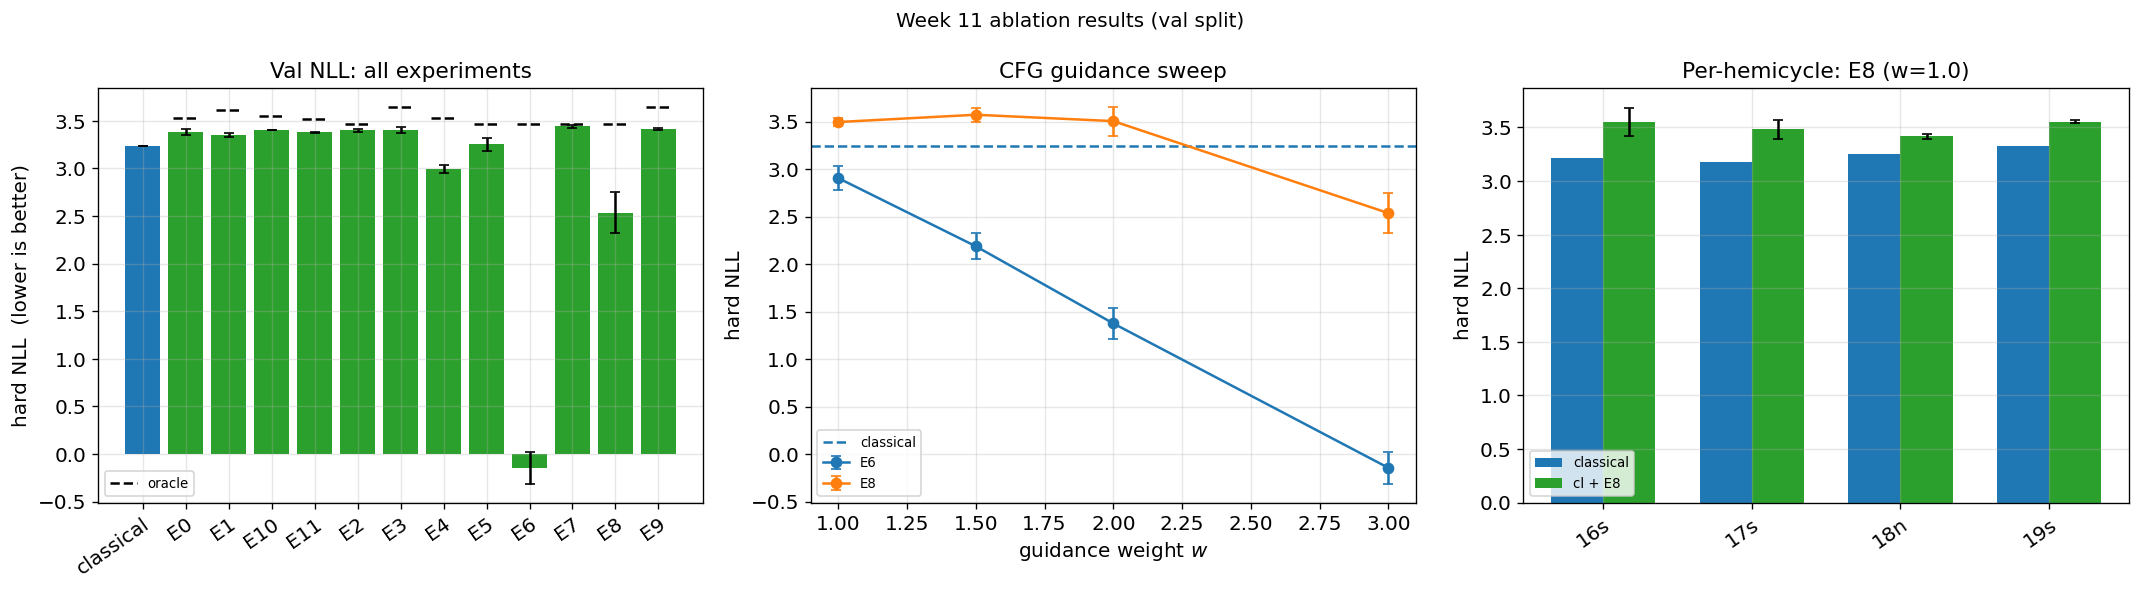

In [36]:
if not EVAL_MODE:
    print("Skipping Task 69 headline plot (MODE=train). Switch MODE to \"eval\" once you have ckpt_E*.ckpt files.")
else:
    # Task 69 — headline plot + CFG sweep + per-hemicycle breakdown.

    # Select the best guidance_w per experiment (lowest nll_mean).
    best_idx = scoreboard.groupby("experiment")["nll_mean"].idxmin()
    best_rows = scoreboard.loc[best_idx].reset_index(drop=True)

    has_cfg = (scoreboard["guidance_w"] > 0.0).any()
    n_panels = 3 if has_cfg else 2
    fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5))

    # ── Panel 1: bar chart of val NLL ──────────────────────────────────
    ax1 = axes[0]
    labels = ["classical"] + list(best_rows["experiment"])
    nll_vals = [nll_cl_val] + list(best_rows["nll_mean"])
    nll_errs = [0.0] + list(best_rows["nll_std"])
    x = np.arange(len(labels))
    colors = ["C0"] + ["C2"] * len(best_rows)

    ax1.bar(x, nll_vals, yerr=nll_errs, color=colors, capsize=3)
    for i, (_, row) in enumerate(best_rows.iterrows()):
        ax1.plot([i + 1 - 0.3, i + 1 + 0.3],
                 [row["oracle_nll_mean"]] * 2,
                 "k--", lw=1.5, label="oracle" if i == 0 else None)
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, rotation=35, ha="right", rotation_mode="anchor")
    ax1.set_ylabel("hard NLL  (lower is better)")
    ax1.set_title("Val NLL: all experiments")
    ax1.legend(fontsize=8)

    # ── Panel 2: CFG guidance sweep (if applicable) ────────────────────
    if has_cfg:
        ax2 = axes[1]
        cfg_rows = scoreboard[scoreboard["guidance_w"] > 0.0]
        for exp_name, grp in cfg_rows.groupby("experiment"):
            grp = grp.sort_values("guidance_w")
            ax2.errorbar(grp["guidance_w"], grp["nll_mean"],
                         yerr=grp["nll_std"], label=exp_name,
                         marker="o", capsize=3)
        ax2.axhline(nll_cl_val, color="C0", ls="--", label="classical")
        ax2.set_xlabel("guidance weight $w$")
        ax2.set_ylabel("hard NLL")
        ax2.set_title("CFG guidance sweep")
        ax2.legend(fontsize=8)
        panel_hc = axes[2]
    else:
        panel_hc = axes[1]

    # ── Panel 3: per-hemicycle breakdown for the best variant ──────────
    # Choose the variant to showcase below. A variant whose mean NLL dips
    # *below* its oracle floor is exploiting the hard-NLL metric via
    # overconfident, over-sharpened samples (density > 1 -> negative NLL),
    # not generalizing -- so disqualify those before picking the "best".
    sb = scoreboard.copy()
    sb["oracle_gap"] = sb["nll_mean"] - sb["oracle_nll_mean"]
    legit = sb[sb["oracle_gap"] >= 0.0]
    if not legit.empty:
        best_sel = legit.loc[legit["nll_mean"].idxmin()]
    else:
        # Every variant beats the oracle: showcase the least overconfident.
        best_sel = sb.loc[sb["oracle_gap"].idxmax()]
    best_name = best_sel["experiment"]
    best_cfg  = EXPERIMENTS[best_name]
    best_w    = float(best_sel["guidance_w"])

    _raw_best = best_rows.loc[best_rows["nll_mean"].idxmin(), "experiment"]
    if best_name != _raw_best:
        print(f"note: lowest-NLL variant {_raw_best} beats its oracle floor "
              f"(over-sharpening, not skill); showcasing {best_name} instead.")

    lit_best, train_ds_best, _, _ = load_trained_experiment(
        best_name, best_cfg, windows_aug, CKPT_DIR, alpha_np, sigma_np,
    )

    cycle_rows = []
    for hc in val_hcs:
        nll_cl_hc, _ = hard_nll_classical(classical, [hc])
        keys_hc, cond_hc = block_cond_concat([hc], lit_best, best_cfg,
                                              train_ds_best)
        cond_K_hc = cond_hc.repeat_interleave(K, dim=0)
        torch.manual_seed(0)
        samp_hc = sample_conditional_extended(
            lit_best, cond_K_hc, guidance_w=best_w, device=device,
        ).cpu().numpy().reshape(len(keys_hc), K, 15)
        nlls_hc, _ = k_run_combined(
            hard_nll_combined, classical, [hc], keys_hc, samp_hc,
        )
        cycle_rows.append({
            "label": f"{hc['cycle']:02d}{hc['hemisphere'][0]}",
            "classical": nll_cl_hc,
            "diff_mean": nlls_hc.mean(),
            "diff_std":  nlls_hc.std(),
        })
    breakdown = pd.DataFrame(cycle_rows)

    x3 = np.arange(len(breakdown))
    w3 = 0.35
    panel_hc.bar(x3 - w3 / 2, breakdown["classical"], width=w3,
                 color="C0", label="classical")
    panel_hc.bar(x3 + w3 / 2, breakdown["diff_mean"],
                 yerr=breakdown["diff_std"], width=w3,
                 color="C2", label=f"cl + {best_name}", capsize=3)
    panel_hc.set_xticks(x3)
    panel_hc.set_xticklabels(breakdown["label"], rotation=35, ha="right", rotation_mode="anchor")
    panel_hc.set_ylabel("hard NLL")
    panel_hc.set_title(f"Per-hemicycle: {best_name} (w={best_w:.1f})")
    panel_hc.legend(fontsize=8)

    fig.suptitle("Week 11 ablation results (val split)", fontsize=12)
    fig.tight_layout()
    plt.show()

---
## Task 70 — Going further

Once you've worked through the Level 1–5 escalation menu in 10d and
want to push further, the tiered menu below ranks the next experiments
by expected payoff per unit effort. Discipline still applies: one knob
at a time, log to wandb, add to `EXPERIMENTS` in both 10d and 10e,
then re-run.

**Level 1 — easy wins**
- **Wider/deeper MLP.** Bump `hidden_dim` from 128 to 256, `n_layers`
  from 3 to 5 in the winning experiment's config. If NLL drops, the
  network was capacity-bound — interesting on its own.
- **Longer K at evaluation.** Bump K from 100 to 500 for the winning
  variant — tightens the K-σ error bar and lets you trust smaller
  margins.
- **Sampler comparison.** Re-score the winner with DDPM (stochastic)
  sampling instead of the deterministic DDIM in
  `sample_conditional_extended`. Deterministic samplers can under-
  disperse, inflating NLL.

**Level 2 — extra cond information**
- **Larger trajectory K.** Bump `K_LAGS` from 4 to 8 in 10d. If the
  trajectory variant's oracle improves but its diffusion doesn't, the
  architecture is underusing the longer history.
- **Lagged opposite-hemisphere.** Pair the trajectory cond with the
  opposite hemisphere — `opp_area_smoothed_lag1..lag4`.

**Level 3 — architectural changes**
- **Cross-attention conditioning.** Replace the FiLM mechanism with
  cross-attention over a small set of learned cond tokens — overkill
  for the cond dim here, but worth knowing if the FiLM gain saturates.
- **Per-bin-aware loss.** Weight the ε-prediction loss by the inverse
  per-bin std so well-resolved bins don't dominate gradients.

**The test set is the PI's.** Every iteration above is val-only. The
final test-set reveal happens once, after the program is closed.

---
## Handoff back to the PI

The headline numbers in `scoreboard` answer two questions:

1. **Does any variant beat the classical baseline on val?** If yes, the
   diffusion approach has earned its place in the final pipeline.
2. **Where is the bottleneck — information or architecture?** Compare
   each row's `nll_mean` to its `oracle_nll_mean`. A large gap means
   the cond set has more information than the diffusion is extracting
   (architecture-bound). A small gap with the oracle near classical
   means the cond set isn't carrying enough information — that line of
   experiments is exhausted; try a different cond group.

The PI will run the test set evaluation on whatever variant the val
results recommend.
